<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/main/RA1_TP3/RA1_Trabajo_pr%C3%A1ctico_N%C2%B0_3%2C_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TP3 - Introducción a clasificaión y regresión

In [ ]:
# @title *Esta celda importa utilidades comunes al colab*
import sys
import os

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from sklearn.preprocessing import LabelEncoder
import warnings

#Ejercicio 1 - Modelado de regresión (Alex)


---
**Dataset:** `propiedades.csv`  
**Grupo:** Numero 8  
**Integrantes:** Acosta Alex, Bareiro Santiago, Borges Agustin  
**Fecha:** x/04/2026

>El equipo de analítica de la empresa inmobiliaria necesita un modelo capaz de estimar el precio de una propiedad a partir de sus características. El objetivo ya no es describir los datos, sino construir un predictor evaluable y defendible.


##1. Construcción del pipeline

##2. Entrenamiento y comparación de modelos

##3. Optimización

#Ejercicio 2 - Modelado de clasificación

---
**Dataset:** `clientes_churn.csv`  
**Grupo:** Numero 8  
**Integrantes:** Acosta alex, Bareiro Santiago, Borges Agustin  
**Fecha:** x/04/26

>La empresa de telecomunicaciones necesita anticipar qué clientes tienen alta probabilidad de abandonar el servicio en el próximo mes, con el objetivo de intervenir a tiempo con ofertas de retención. En este contexto de negocio, detectar un cliente que se va y no actuar tiene un costo estimado de 50000 (pérdida de valor del cliente).
Intervenir innecesaiamente sobre un cliente que no pensaba irse tiene un costo de 8000 (costo de la promoción o descuento otorgado).

## 0. Configuración del entorno

In [ ]:
def load_dataset(path):
    return pd.read_csv(path)

dataset_path = "/content/clientes_churn.csv" # Corrected path to absolute path
df_churn = load_dataset(dataset_path)

SEED = 42

##1. Construcción del pipeline

###1.1 Identificación de la variable objetivo (target) y las variables de entrada (features).


*   **Target:** `churn`
    *   Representa a los cientes que cancelaron el servicio de la empresa.

*   **Variables de Entrada (Features):**
    *   `facturacion_mensual`: Costo monetario por mes del servicio que cobra la empresa a un cliente.
    *   `contrato`: Intervalo temporal que define el momento en el cliente debe de abonar dinero nuevamente para mantener el servicio que le fue popiciado en funcionamiento.
    *   `antiguedad_meses`: Cantidad de tiempo que un cliente utilizo el servicio medido en meses.
    *   `productos`: Numero de productos del que dispone un cliente por la paga del servicio.

In [ ]:
# @title Limpieza de datos (pre-division en *train*/*test*)

# Eliminamos la variable 'id_cliente'
if 'id_cliente' in df_churn.columns:
    df_churn.drop(columns=['id_cliente'], inplace=True)

# Eliminamos las entradas sin el dato de 'facturacion_mensual'
df_churn_clean = df_churn.dropna(subset=['facturacion_mensual']).copy()

# Version del dataset para futuras comparaciones
df_churn_tf = df_churn_clean.drop(columns = 'soporte_tecnico').copy()

# Eliminamos las columnas de 'soporte_tecnico' y 'tiene_fibra' por su poca importancia
df_churn_clean = df_churn_clean.drop(columns=['soporte_tecnico', 'tiene_fibra']).copy()

df_churn_clean.head()

,antiguedad_meses,contrato,facturacion_mensual,productos,churn
0,42,anual,40.64,3.0,0
1,16,mensual,68.57,2.0,1
2,78,bianual,32.38,3.0,1
3,9,anual,63.87,1.0,1
4,1,mensual,68.47,1.0,0


###1.2 Division en *train*/*test* y definicion del pipeline.


In [ ]:
# @title Particiones

# Separamos Features (X) y Target (y)
X = df_churn_clean.drop(columns=['churn'])
y = df_churn_clean['churn']

# Separamos train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)

Dividimos el dataset en un estandar de 30% *test* y 70% *train*, ademas, aplicamos una estratificacion para tomar proporciones iguales de exito y fallo (como en el dataset completo).  

No usaremos una tecnica de sobremuestreo como SMOTE al no tener un besbalance tan grave, sino que optamos por darle peso a las categorias luego en la funcion de costo, teniendo en cuenta ademas que un error de falso negativo (predecir que el cliente no se dara de baja, cuando en realidad si lo hara) tiene una gran importancia para nuestro modelo.

>Codificacion de la variable `contrato`
>
>Para codificar esta variable categórica utilizaremos *Ordinal Encoding*, esto debido a que sus valores tienen un orden lógico, siendo este de menor a mayor tiempo de duracion del mismo.
>
>¿Por qué *Ordinal Encoding* y no *One-Hot Encoding*?
>
>Como mencionamos en el ejercicio 1, utilizar *Ordinal Encoding* implica un orden jerarquico. El no aprovechar esta caracteristica y usar en vez *One-Hot Encoding* significaria perder informacion de como se relacionan las categorias. Ademas no estamos agregando ninuga variable nueva, lo que hace que nuestro dataset se vea mas limpio y sea menos complejo.

In [ ]:
# @title Creacion del Pipeline

# Verificamos los NaNs en X_train y X_test antes del preprocesamiento
print("NaNs en X_train antes de la imputación:")
print(X_train.isnull().sum())
print("\nNaNs en X_test antes de la imputación:")
print(X_test.isnull().sum())

# Identificar las columnas
columnas_numericas = ['antiguedad_meses', 'facturacion_mensual']

# Pipeline para numéricas por mediana
pipeline_numerico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='median')),
    ('escalador', StandardScaler())
])

# Pipeline 'productos'
pipeline_productos = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='most_frequent')),
    ('to_int', FunctionTransformer(lambda x: x.astype(int), validate=False)),
])

# Pipeline para 'contrato'
categorias_contrato = [['mensual', 'anual', 'bianual']]
pipeline_contrato = Pipeline(steps=[
    ('codificador', OrdinalEncoder(categories = categorias_contrato)),
])

# Crear el ColumnTransformer
preprocesador_churn = ColumnTransformer(
    transformers = [
        ('num', pipeline_numerico, columnas_numericas),
        ('prod', pipeline_productos, ['productos']),
        ('cat', pipeline_contrato, ['contrato'])
    ],
    remainder='passthrough'
)

# Aplicar el preprocesamiento
X_train_processed = preprocesador_churn.fit_transform(X_train)
X_test_processed = preprocesador_churn.transform(X_test)

# Reconstrucción de DataFrames para inspección
all_features = columnas_numericas + ['productos'] + ['contrato']

X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_features, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_features, index=X_test.index)

print("\nPrimeras 5 filas de X_train procesado (productos como int):")
display(X_train_processed_df.head())
print("\nTipos de datos en el DataFrame procesado:")
print(X_train_processed_df.dtypes)

NaNs en X_train antes de la imputación:
antiguedad_meses        0
contrato                0
facturacion_mensual     0
productos              43
dtype: int64

NaNs en X_test antes de la imputación:
antiguedad_meses        0
contrato                0
facturacion_mensual     0
productos              16
dtype: int64

Primeras 5 filas de X_train procesado (productos como int):


,antiguedad_meses,facturacion_mensual,productos,contrato
26,-0.571112,0.713825,3.0,0.0
742,2.434521,-1.449622,1.0,2.0
223,1.405195,-0.727865,2.0,2.0
371,0.211176,1.466130,1.0,0.0
588,-1.106362,0.323538,1.0,0.0



Tipos de datos en el DataFrame procesado:
antiguedad_meses       float64
facturacion_mensual    float64
productos              float64
contrato               float64
dtype: object


Decidimos separar las columnas numericas en las que se imputara con la media, de la columna `productos` que ,ademas de imputarse con la moda, se cambia el tipo de dato de *float* a *int*. Por otro lado tenemos una unica columna categorica `contrato` a la que se le realizo su respectiva codificacion. Ademas, se realizara un escalamiento estandarizado ya uno de los enfoques que se utilizara para entrenar el modelo es KNN (*K-Nearest Neighbors*).

>Una aclaracion es que no necesariamente se debe utilizar el escalamiento `StandardScaler`, la idea en KNN es que los rangos sean similares. De todas formas se utilizo ese metodo de escalamiento para todas las variables por mantener cierta consistencia y porque no hay outliers extremos que necesiten de un metodo mas robusto frente a estos como `RobustScaler` (valga la redundancia).

##2. Entrenamiento y comparación de modelos

###2.1 Regresion Logistica

Recordando lo hablado anteriormente, sobre la eleccion del metodo de balance de clases, en este modelo se aplico un peso para que se penalize al modelo 6 veces mas si se equivoca clasificando a la clase `churn=1` que si lo hace con la clase `churn=0`.

--- Regresion Logistica ---

[M3tricas en Entrenamiento]
              precision    recall  f1-score   support

           0       0.93      0.40      0.56       550
           1       0.43      0.94      0.59       264

    accuracy                           0.57       814
   macro avg       0.68      0.67      0.57       814
weighted avg       0.77      0.57      0.57       814


[M3tricas en Test]
              precision    recall  f1-score   support

           0       0.93      0.37      0.53       237
           1       0.41      0.94      0.57       113

    accuracy                           0.55       350
   macro avg       0.67      0.65      0.55       350
weighted avg       0.76      0.55      0.54       350



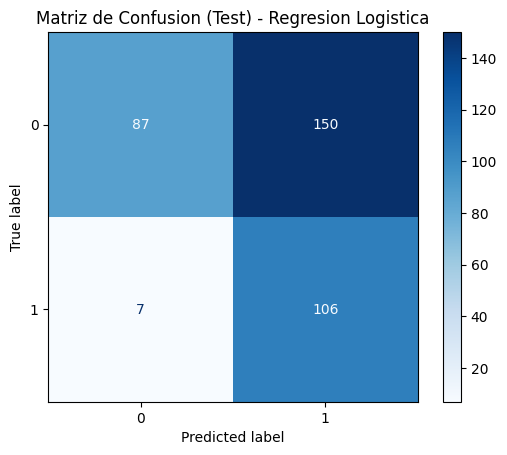

In [ ]:
# @title Entrenamiento y evaluacion de Regresion Logistica

pesos_personalizados = {0: 1, 1: 6}
log_reg = LogisticRegression(class_weight=pesos_personalizados, random_state=SEED)

print("--- Regresion Logistica ---")
log_reg.fit(X_train_processed, y_train)

# Evaluacion en TRAIN
print("\n[M3tricas en Entrenamiento]")
y_train_pred = log_reg.predict(X_train_processed)
print(classification_report(y_train, y_train_pred))

# Evaluacion en TEST
print("\n[M3tricas en Test]")
y_pred_log = log_reg.predict(X_test_processed)
print(classification_report(y_test, y_pred_log))

# Generar y mostrar la matriz de confusion para Test
cm = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg.classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusion (Test) - Regresion Logistica')
plt.show()

Si bien un *accuracy* de 55% no es alto, podemos ver un buen valor en la metrica que mas nos importa, un 94 % de *recall* en `churn=1`. Esto significa que el balance de clases esta bien aplicado y se esta prediciendo con exito y extrema sensibilidad cuando un cliente dara de baja el servicio.

Cabe aclarar que, al mismo tiempo, la baja *precision* en esta clase nos dice que estamos interviniendo innecesariamente el 59 % de las veces cuando enrealidad el cliente no pensaba darse de baja. Este numero se da principalmente por el cambio de peso de las clases y da a parecer que no estamos teniendo demasiado exito, pero debemos tener en cuenta que un falso negativo vale 6,25 veces mas que un falso positivo, asi que una pequeña disminucion del *recall* podria no valer la pena por el aumento de este parametro.

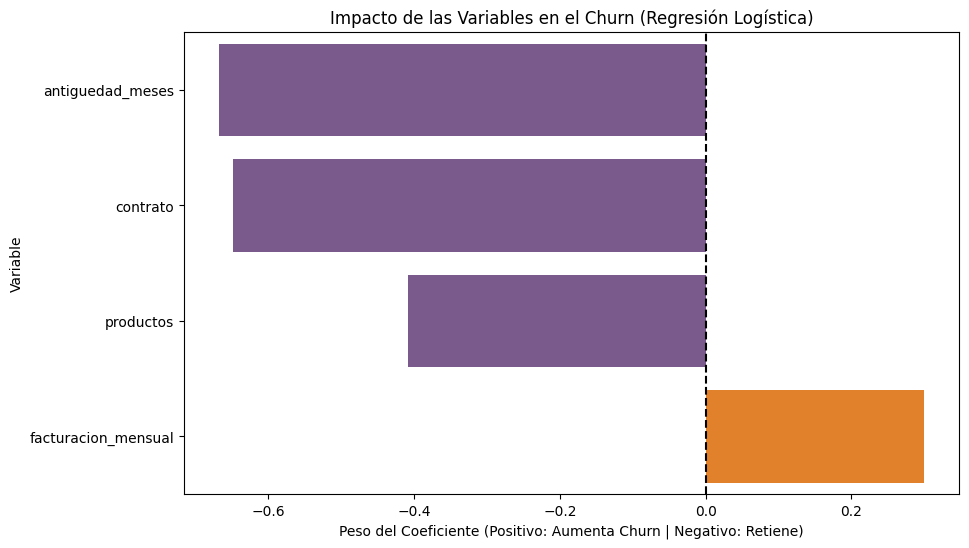

In [ ]:
# @title Interpretacion de los coeficientes del modelo

# 1. Extraer los coeficientes del modelo de Regresión Logística
# Accedemos al modelo directamente a través de la variable log_reg
lr_model = log_reg
coeficientes = lr_model.coef_[0]

# 2. Crear un DataFrame para visualizar mejor
importancia_df = pd.DataFrame({
    'Variable': all_features,
    'Coeficiente': coeficientes
})

# 3. Ordenar por valor absoluto para ver cuáles "mueven más la aguja"
importancia_df['Abs_Coef'] = importancia_df['Coeficiente'].abs()
importancia_df = importancia_df.sort_values(by='Abs_Coef', ascending=False)

# 4. Graficar
plt.figure(figsize=(10, 6))
colors = ['#ff7f0e' if c > 0 else '#7D5194' for c in importancia_df['Coeficiente']]
sns.barplot(x='Coeficiente', y='Variable', data=importancia_df, hue='Variable', palette=colors, legend=False)

plt.axvline(x=0, color='black', linestyle='--') # Línea en el cero
plt.title("Impacto de las Variables en el Churn (Regresión Logística)")
plt.xlabel("Peso del Coeficiente (Positivo: Aumenta Churn | Negativo: Retiene)")
plt.show()

Analizando estos datos podemos afirmar varias de nuestras hipotesis en el EDA. En cuanto a las variables mas influyentes, acertamos por completo con `antiguedad_meses` y `contrato`, mientras que `facturacion_mensual` no tuvo tanto impacto como se creia, pero sigue siendo importante para el analisis junto con `productos`.

###2.2 K-Nearest Neighbors (KNN)

--- K-Nearest Neighbors ---

[Métricas en Entrenamiento] = 0.2:
              precision    recall  f1-score   support

           0       0.92      0.46      0.61       550
           1       0.45      0.92      0.60       264

    accuracy                           0.61       814
   macro avg       0.69      0.69      0.61       814
weighted avg       0.77      0.61      0.61       814


[Métricas en Test] = 0.2:
              precision    recall  f1-score   support

           0       0.90      0.43      0.58       237
           1       0.43      0.90      0.58       113

    accuracy                           0.58       350
   macro avg       0.67      0.67      0.58       350
weighted avg       0.75      0.58      0.58       350



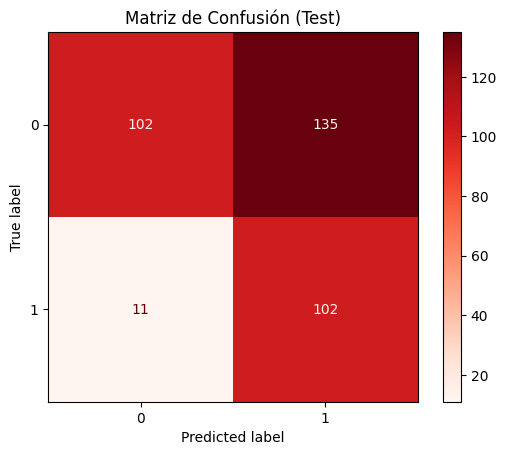

In [ ]:
# @title Entrenamiento y evaluacion de KNN

knn_model = KNeighborsClassifier(n_neighbors=30)

print("--- K-Nearest Neighbors ---")
knn_model.fit(X_train_processed, y_train)

# 1. EVALUACION EN TRAIN
prob_churn_train = knn_model.predict_proba(X_train_processed)[:, 1]
umbral = 0.2
y_pred_train_custom = (prob_churn_train >= umbral).astype(int)

print(f"\n[Métricas en Entrenamiento] = {umbral}:")
print(classification_report(y_train, y_pred_train_custom))

# 2. EVALUACION EN TEST
prob_churn_test = knn_model.predict_proba(X_test_processed)[:, 1]
y_pred_test_custom = (prob_churn_test >= umbral).astype(int)

print(f"\n[Métricas en Test] = {umbral}:")
print(classification_report(y_test, y_pred_test_custom))

# Generar y mostrar la matriz de confusion para Test
cm = confusion_matrix(y_test, y_pred_test_custom)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_model.classes_)
disp.plot(cmap='Reds')
plt.title(f'Matriz de Confusión (Test)')
plt.show()

**Ajuste de desbalance en KNN**  
Como se puede ver en el codigo, se utilizo el metodo `predict_proba(X)` el cual, segun la documentacion oficial, retorna las probabilidades de que una entrada se clasifique en cada una de las clases, mientras que `predict(X)` devuelve la clase a la que se estima que pertenece. Utilizando esta informacion a nuestro favor, podemos agregar un 'peso' a la clase `churn=1` modificando un umbral que determine cuando una entrada pertenece a esta. Normalmente este umbral es de 50 %, pero lo modificaremos para que sea de 20 %, teniendo en cuenta que es preferible tener un falso positivo que un falso negativo.

En este modelo tambien tuvimos resultados exitosos, muy parecidos con el anterior, obteniendo un 90% de *recall* en `churn=1`.

###2.3 Arbol de Decisiones

--- Arbol de Decision ---

[Metricas en Entrenamiento]
              precision    recall  f1-score   support

           0       0.95      0.52      0.68       550
           1       0.49      0.94      0.64       264

    accuracy                           0.66       814
   macro avg       0.72      0.73      0.66       814
weighted avg       0.80      0.66      0.66       814


[Metricas en Test]
              precision    recall  f1-score   support

           0       0.87      0.50      0.64       237
           1       0.45      0.84      0.58       113

    accuracy                           0.61       350
   macro avg       0.66      0.67      0.61       350
weighted avg       0.73      0.61      0.62       350



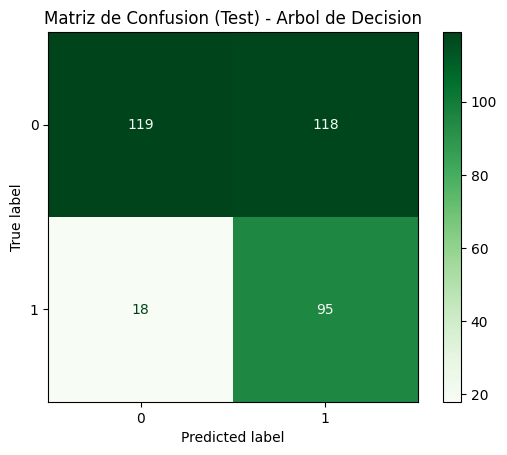

In [ ]:
# @title Entrenamiento y evaluacion con Arbol de Decisiones

# Usamos los mismos pesos para priorizar el Recall de Churn
dtree = DecisionTreeClassifier(class_weight=pesos_personalizados, random_state=SEED, max_depth=5)

print("--- Arbol de Decision ---")
dtree.fit(X_train_processed, y_train)

# Evaluacion en TRAIN
print("\n[Metricas en Entrenamiento]")
y_train_pred_dt = dtree.predict(X_train_processed)
print(classification_report(y_train, y_train_pred_dt))

# Evaluacion en TEST
print("\n[Metricas en Test]")
y_pred_dtree = dtree.predict(X_test_processed)
print(classification_report(y_test, y_pred_dtree))

# Generar y mostrar la matriz de confusion para Test
cm = confusion_matrix(y_test, y_pred_dtree)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dtree.classes_)
disp.plot(cmap='Greens')
plt.title('Matriz de Confusion (Test) - Arbol de Decision')
plt.show()

Hasta ahora parece ser el mejor modelo si vemos solo su *accuracy*, pero en realidad es el modelo que tuvo peor desempeño, teniendo menos aciertos que los anteriores a la hora de predecir que clientes dejaran de utilizar el servicio  

Si utilizamos las matrices de confusion para una comparacion, esos 11 clientes que no pudimos mantener, nos cuestan mas que los 32 clientes a los que hicimos ofertas inecesarias.

In [ ]:
# @title Comparacion de costos

# Definición de costos
costo_fp = 8000
costo_fn = 50000

# Extracción dinámica de FP y FN de los modelos evaluados en las celdas anteriores
# Regresión Logística
cm_log = confusion_matrix(y_test, y_pred_log)
fp_log = cm_log[0, 1]
fn_log = cm_log[1, 0]

# Árbol de Decisión
cm_dt = confusion_matrix(y_test, y_pred_dtree)
fp_dt = cm_dt[0, 1]
fn_dt = cm_dt[1, 0]

datos_costos = {
    'Modelo': ['Regresión Logística', 'Árbol de Decisión'],
    'Falsos Positivos (FP)': [fp_log, fp_dt],
    'Falsos Negativos (FN)': [fn_log, fn_dt]
}

df_comparacion = pd.DataFrame(datos_costos)

# Cálculos de costos
df_comparacion['Costo FP'] = df_comparacion['Falsos Positivos (FP)'] * costo_fp
df_comparacion['Costo FN'] = df_comparacion['Falsos Negativos (FN)'] * costo_fn
df_comparacion['Costo Total'] = df_comparacion['Costo FP'] + df_comparacion['Costo FN']

# Mostrar el cuadro
print("Comparativa de Costos")
display(df_comparacion.style.format({
    'Costo FP': '${:,.0f}',
    'Costo FN': '${:,.0f}',
    'Costo Total': '${:,.0f}'
}))

diferencia = df_comparacion.loc[1, 'Costo Total'] - df_comparacion.loc[0, 'Costo Total']
print(f"\nLa diferencia de dinero ahorrado usando Regresión Logística es de: ${diferencia:,.0f}")

Comparativa de Costos


,Modelo,Falsos Positivos (FP),Falsos Negativos (FN),Costo FP,Costo FN,Costo Total
0,Regresión Logística,150,7,"$1,200,000","$350,000","$1,550,000"
1,Árbol de Decisión,118,18,"$944,000","$900,000","$1,844,000"



La diferencia de dinero ahorrado usando Regresión Logística es de: $294,000


###Comparacion con la variable `tiene_fibra` incluida

Antes de pasar a la optimizacion, decidimos realizar este ultimo analisis con la variable `tiene_fibra`, ya que pensamos que puede llegar a mejorar las predicciones aunque se un poco. Solo probaremos con esta *feature* y no con `soporte_tecnico` ya que nos parece una variable que aporta menos informacion y no tuvo ni un poco de relacion con el resto de variables en el analisis EDA.

In [ ]:
# @title Particiones

# Separamos Features (X) y Target (y)
Xtf = df_churn_tf.drop(columns=['churn'])
ytf = df_churn_tf['churn']

# Separamos train y test
Xtf_train, Xtf_test, ytf_train, ytf_test = train_test_split(
    Xtf, ytf, test_size=0.30, stratify=ytf, random_state=SEED
)

In [ ]:
# @title Creacion del Pipeline

# Crear el ColumnTransformer
preprocesador_churn_tf = ColumnTransformer(
    transformers = [
        ('num', pipeline_numerico, columnas_numericas),
        ('prod', pipeline_productos, ['productos']),
        ('cat', pipeline_contrato, ['contrato'])
    ],
    remainder='passthrough'
)

# Aplicar el preprocesamiento
Xtf_train_processed = preprocesador_churn_tf.fit_transform(Xtf_train)
Xtf_test_processed = preprocesador_churn_tf.transform(Xtf_test)

# Reconstrucción de DataFrames para inspección
# Definimos correctamente las 5 columnas resultantes
all_features_tf = columnas_numericas + ['productos', 'contrato', 'tiene_fibra']

# Usamos la lista de 5 nombres para los datos que tienen 5 columnas
Xtf_train_processed = pd.DataFrame(Xtf_train_processed, columns=all_features_tf, index=Xtf_train.index)
Xtf_test_processed = pd.DataFrame(Xtf_test_processed, columns=all_features_tf, index=Xtf_test.index)

print("\nPrimeras 5 filas de X_train procesado (incluyendo tiene_fibra):")
display(Xtf_train_processed.head())
print("\nTipos de datos en el DataFrame procesado:")
print(Xtf_train_processed.dtypes)


Primeras 5 filas de X_train procesado (incluyendo tiene_fibra):


,antiguedad_meses,facturacion_mensual,productos,contrato,tiene_fibra
26,-0.571112,0.713825,3.0,0.0,1.0
742,2.434521,-1.449622,1.0,2.0,1.0
223,1.405195,-0.727865,2.0,2.0,0.0
371,0.211176,1.466130,1.0,0.0,1.0
588,-1.106362,0.323538,1.0,0.0,1.0



Tipos de datos en el DataFrame procesado:
antiguedad_meses       float64
facturacion_mensual    float64
productos              float64
contrato               float64
tiene_fibra            float64
dtype: object


--- Regresion Logistica ---

[M3tricas en Entrenamiento]
              precision    recall  f1-score   support

           0       0.93      0.40      0.56       550
           1       0.43      0.94      0.59       264

    accuracy                           0.57       814
   macro avg       0.68      0.67      0.57       814
weighted avg       0.77      0.57      0.57       814


[M3tricas en Test]
              precision    recall  f1-score   support

           0       0.93      0.37      0.53       237
           1       0.41      0.94      0.57       113

    accuracy                           0.55       350
   macro avg       0.67      0.65      0.55       350
weighted avg       0.76      0.55      0.54       350



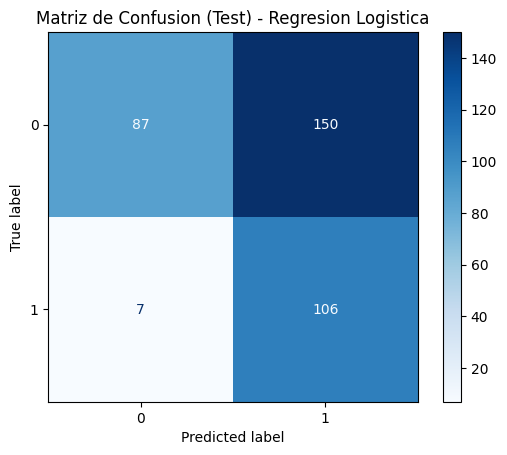

In [ ]:
# @title Entrenamiento y evaluacion de Regresion Logistica

pesos_personalizados = {0: 1, 1: 6}
log_reg_tf = LogisticRegression(class_weight=pesos_personalizados, random_state=SEED)

print("--- Regresion Logistica ---")
log_reg_tf.fit(Xtf_train_processed, ytf_train)

# Evaluacion en TRAIN
print("\n[M3tricas en Entrenamiento]")
ytf_train_pred = log_reg_tf.predict(Xtf_train_processed)
print(classification_report(ytf_train, ytf_train_pred))

# Evaluacion en TEST
print("\n[M3tricas en Test]")
ytf_pred_log = log_reg_tf.predict(Xtf_test_processed)
print(classification_report(ytf_test, ytf_pred_log))

# Generar y mostrar la matriz de confusion para Test
cm = confusion_matrix(ytf_test, ytf_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg_tf.classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusion (Test) - Regresion Logistica')
plt.show()

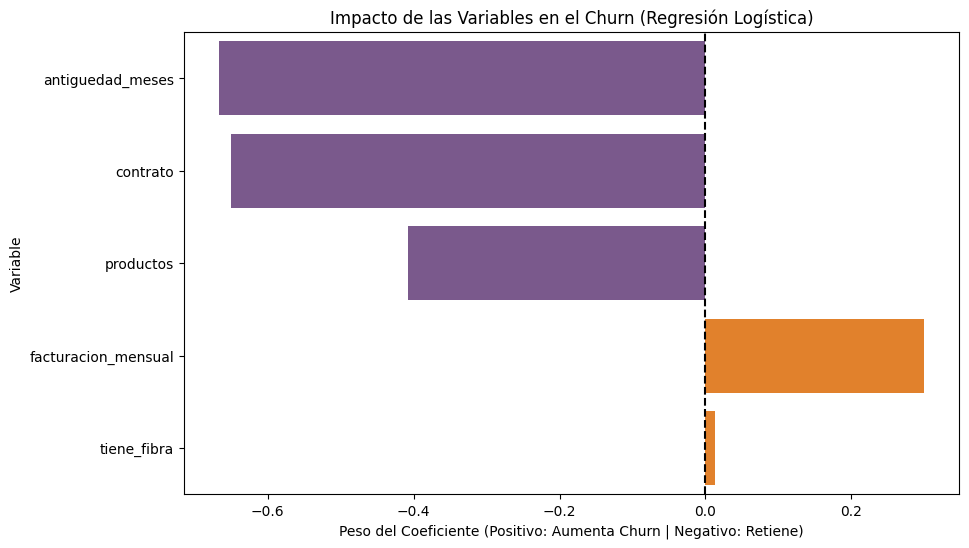

In [ ]:
# @title Interpretacion de los coeficientes del modelo

# 1. Extraer los coeficientes del modelo de Regresión Logística
# Accedemos al modelo directamente a través de la variable log_reg
lr_model = log_reg_tf
coeficientes = lr_model.coef_[0]

# 2. Crear un DataFrame para visualizar mejor
importancia_df = pd.DataFrame({
    'Variable': all_features_tf,
    'Coeficiente': coeficientes
})

# 3. Ordenar por valor absoluto para ver cuáles "mueven más la aguja"
importancia_df['Abs_Coef'] = importancia_df['Coeficiente'].abs()
importancia_df = importancia_df.sort_values(by='Abs_Coef', ascending=False)

# 4. Graficar
plt.figure(figsize=(10, 6))
colors = ['#ff7f0e' if c > 0 else '#7D5194' for c in importancia_df['Coeficiente']]
sns.barplot(x='Coeficiente', y='Variable', data=importancia_df, hue='Variable', palette=colors, legend=False)

plt.axvline(x=0, color='black', linestyle='--') # Línea en el cero
plt.title("Impacto de las Variables en el Churn (Regresión Logística)")
plt.xlabel("Peso del Coeficiente (Positivo: Aumenta Churn | Negativo: Retiene)")
plt.show()

Se puede apreciar que no hay mejoria en las predicciones del modelo al incluir esta variable, por lo que estuvo bien afirmar anteriormente su identidad como ruido.

##3. Optimización

In [ ]:
# Definir el modelo base con el balance de clases
lr_base = LogisticRegression(class_weight=pesos_personalizados, random_state=SEED)

# Definir la cuadricula de hiperparametros ampliada
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'max_iter': [100, 200, 500, 1000],
}

# Configurar GridSearchCV
grid_search_lr = GridSearchCV(
    estimator=lr_base,
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1',
    verbose=1
)

# Ejecutar la busqueda
print("Iniciando busqueda de hiperparametros para Regresion Logistica...")
grid_search_lr.fit(X_train_processed, y_train)

# Mostrar resultados
print(f"\nMejores hiperparametros: {grid_search_lr.best_params_}")
print(f"Mejor F1-Score (Cross-validation): {grid_search_lr.best_score_:.4f}")

# Evaluar el mejor modelo en el conjunto de prueba
best_lr = grid_search_lr.best_estimator_
y_pred_opt = best_lr.predict(X_test_processed)

print("\n[Reporte de Clasificacion - Modelo Optimizado]")
print(classification_report(y_test, y_pred_opt))

Iniciando busqueda de hiperparametros para Regresion Logistica...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Mejores hiperparametros: {'C': 1, 'max_iter': 100}
Mejor F1-Score (Cross-validation): 0.5870

[Reporte de Clasificacion - Modelo Optimizado]
              precision    recall  f1-score   support

           0       0.93      0.37      0.53       237
           1       0.41      0.94      0.57       113

    accuracy                           0.55       350
   macro avg       0.67      0.65      0.55       350
weighted avg       0.76      0.55      0.54       350



In [ ]:
# Definir el modelo base con el balance de clases
dt_base = DecisionTreeClassifier(class_weight=pesos_personalizados, random_state=SEED)

# Definir la cuadricula de hiperparametros ampliada
param_grid_dt = {
    'max_depth': [1, 3, 5, 7, 10, 15, 20],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 20], # Nuevo: min de muestras en hojas
}

# Configurar GridSearchCV
grid_search_dt = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid_dt,
    cv=5,
    scoring='f1',
    verbose=1
)

# Ejecutar la busqueda
print('Iniciando busqueda de hiperparametros para DecisionTreeClassifier...')
grid_search_dt.fit(X_train_processed, y_train)

# Mostrar resultados
print(f'\nMejores hiperparametros: {grid_search_dt.best_params_}')
print(f'Mejor F1-Score (Cross-validation): {grid_search_dt.best_score_:.4f}')

# Evaluar el mejor modelo en el conjunto de prueba
best_dt = grid_search_dt.best_estimator_
y_pred_dt_opt = best_dt.predict(X_test_processed)

print('\n[Reporte de Clasificacion - Arbol de Decision Optimizado]')
print(classification_report(y_test, y_pred_dt_opt))

Iniciando busqueda de hiperparametros para DecisionTreeClassifier...
Fitting 5 folds for each of 224 candidates, totalling 1120 fits

Mejores hiperparametros: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Mejor F1-Score (Cross-validation): 0.5909

[Reporte de Clasificacion - Arbol de Decision Optimizado]
              precision    recall  f1-score   support

           0       0.87      0.49      0.63       237
           1       0.44      0.85      0.58       113

    accuracy                           0.61       350
   macro avg       0.66      0.67      0.60       350
weighted avg       0.73      0.61      0.61       350



Estos resultados nos dicen que inclusive luego de realizar la optimizacion de ambos modelos, no cambian mucho de los resultados originales, dejando como favorito al modelo de Regresion Logistica.

##4. Conclusiones

Una vez finalizado este analisis, podemos afirmar empiricamente lo siguiente:
- Las variables con mas influencia a la hora de predecir si un cliente dara de baja el servicio son la antiguedad y tipo de contrato de este. Esto quiere decir que hay que prestar atencion a los clientes nuevos con contratos de corto plazo, ya que tendria sentido asumir que estan probando el servicio antes de tomar una decision medianamente definitiva.
- Se confirmo que la presencia de la variable `tiene_fibra` genera ruido en nuestras predicciones.
- El balanceo de clases con los pesos nos permitio tener una tasa de exito mucho mas alta en predecir la categoria de interes `churn=1`, sacrificando parcialmente la prediccion de `churn=0`.
- El modelo de regresion logistica es el mas adecuado para esta situacion, ya que los modelos no lineales, solo agregan complejidad e inclusive empeoran las predicciones.

#Ejercicio 3 - Modelado en ausencia de contexto

---
**Dataset:** `dataset_desconocido.csv`  
**Grupo:** Numero 8  
**Integrantes:** Acosta alex, Bareiro Santiago, Borges Agustin  
**Fecha:** x/04/26

>En la etapa de exploración se descrubrió que la estructura de separación entre clases en este dataset es no lineal. Ahora se traducirá esa intuición en decisiones concretas de modelado y verificará empiricamente su validez.

---
##1. Preparación y preprocesamiento de los datos

En primera instancia, se realiza la carga del dataset a usar y un repaso de las hipótesis planteadas en la etapa anterior (EDA).

In [ ]:
df = pd.read_csv("dataset_desconocido.csv")

print(f"Dimensiones: {df.shape}")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nFaltantes:\n{df.isnull().sum()}")
print(f"\nPrimeras filas:")
df.head()

Dimensiones: (1000, 7)

Tipos de datos:
x1        float64
x2        float64
x3        float64
x4        float64
x5        float64
x6        float64
target      int64
dtype: object

Faltantes:
x1        19
x2        13
x3        18
x4         0
x5         0
x6         0
target     0
dtype: int64

Primeras filas:


,x1,x2,x3,x4,x5,x6,target
0,-2.11,1.86,-1.20,0.81,0.67,-0.40,0
1,0.01,-1.05,-0.75,-0.38,-1.38,-0.12,1
2,5.40,-5.65,-0.80,-1.73,-1.72,-1.52,1
3,1.04,-0.14,0.18,-1.26,-1.34,0.75,1
4,-1.00,-1.73,1.53,-1.94,0.81,0.15,0


Cómo en la etapa anterior no se realizó una limpieza por desconocimiento del contexto y falta de herramientas para saber si en primera instancia imputar o eliminar los valores faltantes, actualmente se tomó la decisión de eliminar estos valores dado que representan un 5% de los datos del dataset (50 valores faltantes sobre 1000).

In [ ]:
df_cleaned = df.dropna()
print(f"Dimensiones después de eliminar nulos: {df_cleaned.shape}")
print(f"Faltantes después de eliminar nulos:\n{df_cleaned.isnull().sum()}")

Dimensiones después de eliminar nulos: (950, 7)
Faltantes después de eliminar nulos:
x1        0
x2        0
x3        0
x4        0
x5        0
x6        0
target    0
dtype: int64


El objetivo mediante el siguiente desarrollo es contrastar empíricamente las siguientes hipótesis planteadas en la etapa anterior:
1. Como el target se encuentra balanceado, las métricas de evaluación serán más fiables.
2. Las variables `x1` y `x2` son las únicas altamente relevantes debido a sus distribuciones diferenciadas por clase.
3. `x3`, `x4`, `x5` y `x6` son ruido (distribuciones con alto solapamiento o idénticas por clase). Deben ser eliminadas para evitar sobreajuste y degradación del modelo.
4. La relación entre `x1` y `x2` es circular, no linealmente separable en su espacio original.
5. Para `x1` y `x2`, es crucial aplicar una transformación cuadrática o calcular la distancia desde el origen, ya que esto lineariza la frontera de decisión.
6. Existen outliers en `x1` y `x2`. Aunque no impiden la separabilidad visual con transformaciones, su manejo podría mejorar la robustez del modelo.

####1.2 Definición de features y target

In [ ]:
# Variable objetivo
TARGET = "target"

# Features que usaremos (basado en las hipótesis de relevancia)
FEATURES = ["x1", "x2"]

# Variables que excluimos y por qué:
excluidas = {
    "x3": "Ruido aleatorio: solapamiento casi perfecto entre clases observado en el EDA.",
    "x4": "Ruido puro: distribuciones idénticas por clase y correlación cero.",
    "x5": "Ruido puro: detectado como no relevante en la etapa de exploración.",
    "x6": "Ruido puro: su inclusión podría degradar el desempeño del modelo.",
}

print("Features seleccionadas:", FEATURES)
print(f"\nVariables excluidas:")
for var, razon in excluidas.items():
    print(f"- {var}: {razon}")

Features seleccionadas: ['x1', 'x2']

Variables excluidas:
- x3: Ruido aleatorio: solapamiento casi perfecto entre clases observado en el EDA.
- x4: Ruido puro: distribuciones idénticas por clase y correlación cero.
- x5: Ruido puro: detectado como no relevante en la etapa de exploración.
- x6: Ruido puro: su inclusión podría degradar el desempeño del modelo.


Se excluye la variable `x3` debido a que en el análisis exploratorio (EDA) se observó un solapamiento casi perfecto entre clases. Al no presentar patrones de separación útiles, se comporta como ruido aleatorio, similar a `x4`, `x5` y `x6`.

####1.3 División train/test

Para evitar data leakage, antes determinar que hacer con los outliers, se realiza una división train/test, así se puede realizar un posterior escalado estandar sin que este sea contaminado implicitamente por el modelo de test.

In [ ]:
X = df_cleaned[FEATURES]
y = df_cleaned[TARGET]

# Dividimos usando stratify directamente sobre y, ya que es una clasificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

print(f"Tamaño entrenamiento: {len(X_train)} muestras ({len(X_train)/len(df_cleaned)*100:.0f}%)")
print(f"Tamaño test:          {len(X_test)} muestras ({len(X_test)/len(df_cleaned)*100:.0f}%)")

Tamaño entrenamiento: 760 muestras (80%)
Tamaño test:          190 muestras (20%)


Se eligió una división 80/20 ya que es una proporción aceptada para que el modelo aprenda los patrones con pocas muestras.:

Para el análisis de los outliers, se usó el método del Rango Intercuartílico (IQR) para detectar valores extremos en variables de entrada (X_train), como se eliminan filas, hay que eliminar tanto valores de entrada como objetivo (y_train) para evitar desincronización.


In [ ]:
#cálculo Q1 y Q3  para las columnas relevantes en el set de entrenamiento
Q1 = X_train[['x1', 'x2']].quantile(0.25)
Q3 = X_train[['x1', 'x2']].quantile(0.75)
IQR = Q3 - Q1

#definición de los límites inferior y superior
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#creación de una máscara booleana para identificar filas que NO son outliers en ninguna de las dos columnas
# .all(axis=1) asegura que la fila se mantenga solo si todas sus columnas seleccionadas están dentro de los límites
mask = ((X_train[['x1', 'x2']] >= lower_bound) & (X_train[['x1', 'x2']] <= upper_bound)).all(axis=1)

#se aplica el filtrado a X_train e y_train simultáneamente para mantener la alineación
X_train = X_train[mask]
y_train = y_train[mask]

print(f"Muestras eliminadas por outliers: {len(mask) - mask.sum()}")
print(f"Nuevo tamaño de X_train: {X_train.shape}")
print(f"Nuevo tamaño de y_train: {y_train.shape}")

Muestras eliminadas por outliers: 55
Nuevo tamaño de X_train: (705, 2)
Nuevo tamaño de y_train: (705,)


El proceso consistió en calcular los umbrales estadísticos basados en el Rango Intercuartílico (IQR) para las variables predictoras. Aquellas observaciones que superaron los límites superior o inferior (1.5 * IQR) fueron consideradas ruidos o valores extremos y eliminadas. Esta limpieza se aplicó sincrónicamente tanto a las características (`X_train`) como al objetivo (`y_train`) para garantizar la integridad de los datos de entrenamiento.

---
##2. Entrenamiento y comparación de modelos


MODELO: Regresión Logística (Escalada)
Accuracy (ENTRENAMIENTO): 0.5830
Accuracy (PRUEBA):        0.5579
Tiempo de Inferencia:     2.7966 ms
Diferencia (Train-Test):  0.0251

Reporte de Clasificación (Conjunto de Prueba):
              precision    recall  f1-score   support

           0       0.56      1.00      0.72       106
           1       0.00      0.00      0.00        84

    accuracy                           0.56       190
   macro avg       0.28      0.50      0.36       190
weighted avg       0.31      0.56      0.40       190



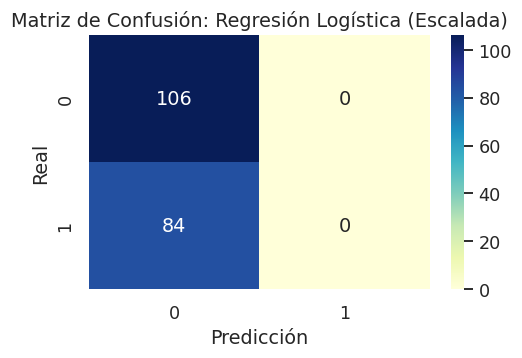


MODELO: K-Nearest Neighbors (Escalado)
Accuracy (ENTRENAMIENTO): 0.9333
Accuracy (PRUEBA):        0.9105
Tiempo de Inferencia:     5.0848 ms
Diferencia (Train-Test):  0.0228

Reporte de Clasificación (Conjunto de Prueba):
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       106
           1       0.89      0.92      0.90        84

    accuracy                           0.91       190
   macro avg       0.91      0.91      0.91       190
weighted avg       0.91      0.91      0.91       190



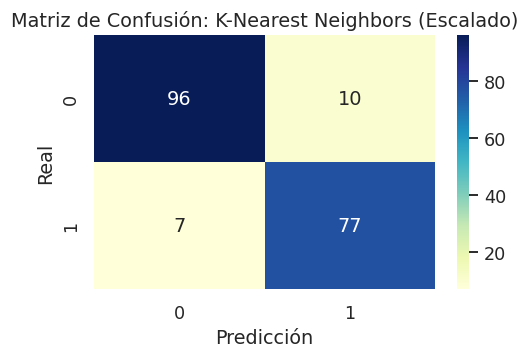


MODELO: Árbol de Decisión (Sin escalar)
Accuracy (ENTRENAMIENTO): 1.0000
Accuracy (PRUEBA):        0.8211
Tiempo de Inferencia:     2.6054 ms
Diferencia (Train-Test):  0.1789

Reporte de Clasificación (Conjunto de Prueba):
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       106
           1       0.81      0.77      0.79        84

    accuracy                           0.82       190
   macro avg       0.82      0.82      0.82       190
weighted avg       0.82      0.82      0.82       190



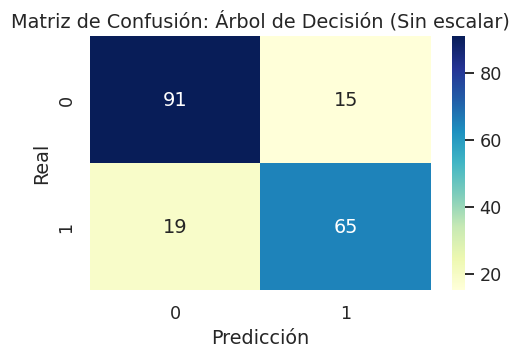

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Definición de modelos y pipelines
models = {
    "Regresión Logística (Escalada)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(random_state=SEED))
    ]),
    "K-Nearest Neighbors (Escalado)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier())
    ]),
    "Árbol de Decisión (Sin escalar)": Pipeline([
        ("clf", DecisionTreeClassifier(random_state=SEED))
    ])
}

# Entrenamiento e iteración para evaluación
for name, model_pipeline in models.items():
    # Ajuste del pipeline completo
    model_pipeline.fit(X_train, y_train)

    # Predicciones para entrenamiento
    y_pred_train = model_pipeline.predict(X_train)

    # Medición del tiempo de inferencia en el conjunto de prueba
    start_time = time.time()
    y_pred_test = model_pipeline.predict(X_test)
    end_time = time.time()
    inference_time = (end_time - start_time) * 1000 # milisegundos

    # Cálculo de métricas
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)

    # Reporte de resultados
    print(f"\n{'='*60}")
    print(f"MODELO: {name}")
    print(f"Accuracy (ENTRENAMIENTO): {acc_train:.4f}")
    print(f"Accuracy (PRUEBA):        {acc_test:.4f}")
    print(f"Tiempo de Inferencia:     {inference_time:.4f} ms")
    print(f"Diferencia (Train-Test):  {abs(acc_train - acc_test):.4f}")

    print("\nReporte de Clasificación (Conjunto de Prueba):")
    print(classification_report(y_test, y_pred_test))

    # Matriz de Confusión
    plt.figure(figsize=(5, 3))
    cm = confusion_matrix(y_test, y_pred_test)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=True)
    plt.title(f'Matriz de Confusión: {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

Tras el entrenamiento y la evaluación de los modelos, se desprenden conclusiones relevantes sobre el comportamiento de los algoritmos en función de la estructura de los datos y su eficiencia computacional:

1. **Regresión Logística (Línea de base)**:
Este modelo presentó el desempeño más bajo (~56% accuracy). Al ser un modelo lineal, es incapaz de capturar la frontera circular. En cuanto a eficiencia, suele ser el más rápido debido a que su inferencia es una simple operación matemática lineal.

2. **Modelos No Lineales: Árboles y KNN**:
*   **Árbol de Decisión:** Logró un 82% de accuracy. Su **tiempo de inferencia** es intermedio; aunque es rápido, la profundidad del árbol puede influir en la velocidad de respuesta.
*   **KNN (K-Nearest Neighbors):** Fue el mejor modelo en precisión (91%). Sin embargo, es importante notar que su **tiempo de inferencia** suele ser el más elevado (en milisegundos). Esto se debe a que KNN es un algoritmo 'lazy learner' que debe calcular la distancia entre la nueva muestra y todos los puntos del conjunto de entrenamiento para decidir la clase, lo que lo hace más costoso computacionalmente en la fase de predicción comparado con los otros modelos.

---
Una vez hecha la comparación de los modelos, se procede a responder las siguientes preguntas:  
* **¿La regresión logística logra capturar la estructura de los datos?**  
No. La Regresión Logística falló totalmente al intentar entender la forma circular de los datos. Al ser un modelo lineal, lo único que puede hacer es trazar una línea recta para separar los grupos. Como en ese caso la clase 1 está rodeada por la clase 0, no hay forma de que una línea recta los separe bien.

* **¿Qué resultado esperábamos antes de entrenarla y qué obtuvimos realmente?**
  *   **Lo que se esperaba:** Por lo que se vió en la etapa de exploración (EDA), ya había una noción de que le iba a ir mal al modelo. Al ver esos círculos concéntricos, era casi seguro que un modelo lineal iba a quedar muy simple (**Underfitting**) y no iba a ofrecer un resultado desempeñador.
  *   **Lo que pasó realmente:** Los números confirmaron esta sospecha. El accuracy fue de ~56%, que es el equivalente a querer "adivinar" el resultado. Lo más claro fue el **Recall de 0% para la clase 1**, lo que nos muestra que el modelo directamente no 'vio' el círculo central y predijo casi todo como clase 0.

* **¿Cuál de los modelos no lineales logra un mejor desempeño?**  
El modelo que logró el mejor desempeño fue **KNN (K-Nearest Neighbors)**, alcanzando un accuracy del **91%**. Si bien el Árbol de Decisión también superó ampliamente al modelo lineal (82%), el KNN fue más preciso y mostró una mejor capacidad de generalización entre el entrenamiento y la prueba.

* **¿Cómo se vincula este resultado con la forma de la frontera de decisión imaginada durante el EDA?**
Este resultado confirma totalmente lo que se planteó en la etapa de exploración (EDA):

  *   **KNN y la Circularidad:** Dado que en el EDA se observó que la clase 1 formaba un círculo central rodeado por la clase 0, un modelo basado en distancias como KNN es ideal. Al calcular los vecinos más cercanos, el KNN puede trazar una frontera curva y "suave" que sigue la geometría circular de manera natural. Sin embargo, esta precisión tiene un costo en el **tiempo de inferencia**, ya que el algoritmo debe buscar en todo el dataset de entrenamiento para clasificar cada punto nuevo.
  *   **Árboles y los cortes rectos:** El Árbol de Decisión, por su naturaleza, solo puede realizar particiones perpendiculares a los ejes (líneas rectos). Para intentar rodear una estructura circular, el árbol debe realizar muchísimos cortes sucesivos en forma de 'escalera' o rectángulos. Esto hace que su frontera sea más tosca y proclive al sobreajuste, lo que explica por qué su accuracy fue menor comparado con KNN, aunque su velocidad de inferencia suele ser superior al no depender de cálculos de distancia globales.

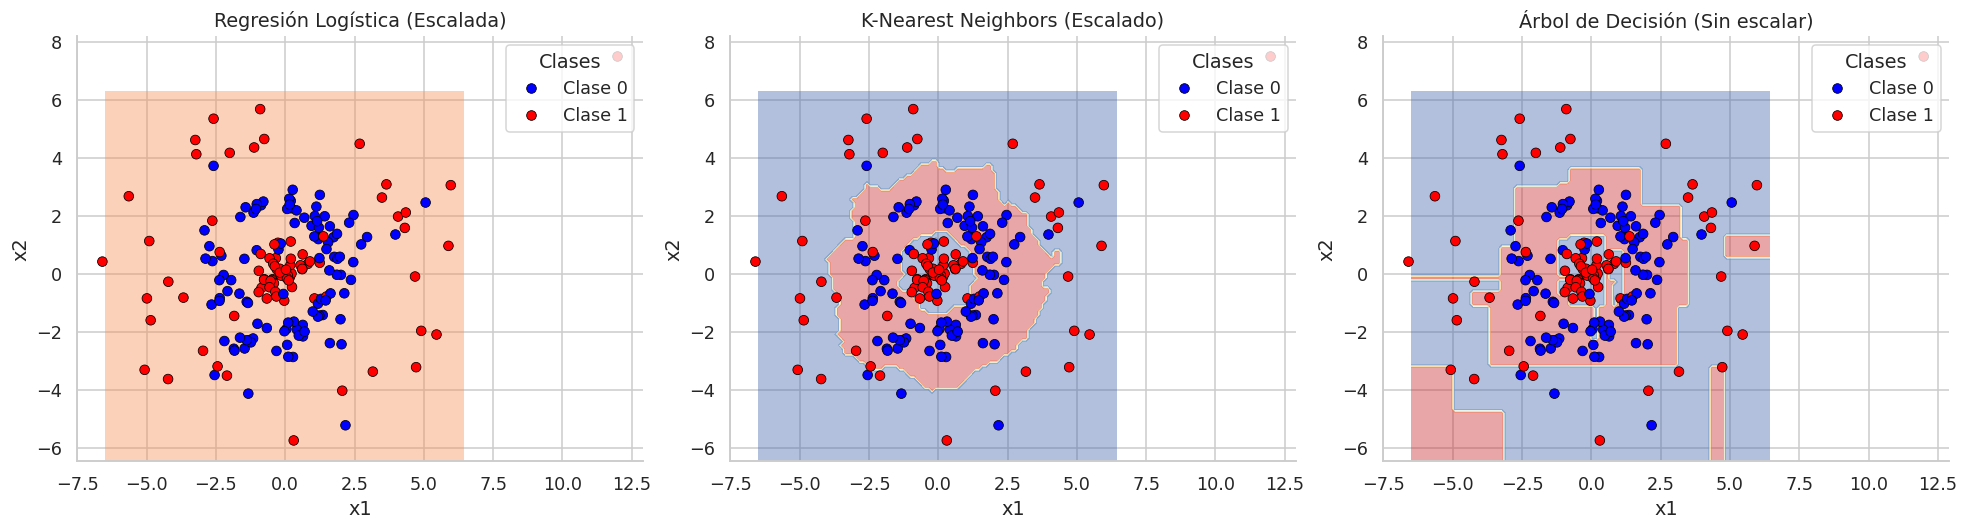

In [ ]:
from sklearn.inspection import DecisionBoundaryDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Iteración sobre los modelos entrenados en el diccionario 'models'
for ax, (name, pipeline) in zip(axes, models.items()):

    # 1. Grafico de las regiones de decisión usando el pipeline completo
    DecisionBoundaryDisplay.from_estimator(
        pipeline,
        X_train,
        ax=ax,
        response_method="predict",
        cmap="RdYlBu",
        alpha=0.4
    )

    # 2. Superposición del scatter plot de los datos de prueba
    sns.scatterplot(
        x=X_test["x1"],
        y=X_test["x2"],
        hue=y_test,
        palette={0: "blue", 1: "red"},
        edgecolor="black",
        s=40,
        ax=ax
    )

    # 3. Configuración estética
    ax.set_title(name)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['Clase 0', 'Clase 1'], title="Clases", loc='upper right')

plt.tight_layout()
plt.show()

El siguiente paso es la inclusión de la distancia cuadrática al origen entre las variables $x1$ y $x2$ como feature, con el objetivo tal de determinar si varía el desempeño de la Regresión Logística:

--- RESULTADOS CON FEATURE ENGINEERING ---
Accuracy (PRUEBA): 0.6895


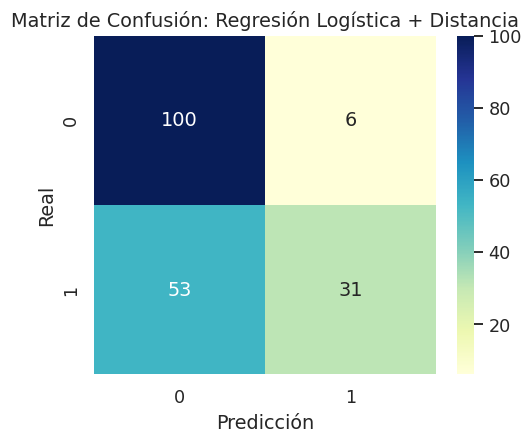

In [ ]:
X_train_eng = X_train.copy()
X_test_eng = X_test.copy()

# Creación de la nueva feature
X_train_eng['dist'] = X_train_eng['x1']**2 + X_train_eng['x2']**2
X_test_eng['dist'] = X_test_eng['x1']**2 + X_test_eng['x2']**2

log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(random_state=SEED))
])

log_reg_pipeline.fit(X_train_eng, y_train)

y_pred_test = log_reg_pipeline.predict(X_test_eng)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"--- RESULTADOS CON FEATURE ENGINEERING ---")
print(f"Accuracy (PRUEBA): {acc_test:.4f}")

plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=True)
plt.title('Matriz de Confusión: Regresión Logística + Distancia')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

Tras el proceso de limpieza, entrenamiento y Feature Engineering, se extraen las siguientes conclusiones clave:

* Los datos presentan una estructura concéntrica donde la Clase 1 está rodeada por la Clase 0. Esto hace que cualquier modelo puramente lineal (como la Regresión Logística original) falle críticamente, obteniendo un *Recall* de 0% para la clase minoritaria.
* El modelo **K-Nearest Neighbors (KNN)** fue el ganador con un **91% de accuracy**. Al basarse en distancias locales, captura la frontera circular de forma natural sin necesidad de transformaciones adicionales.
* Al crear la variable `dist` ($x1^2 + x2^2$), logramos 'linealizar' el espacio. Esto permitió que la Regresión Logística mejorara su desempeño notablemente (de 56% a 69% de accuracy), demostrando que el conocimiento del dominio puede compensar las limitaciones de un algoritmo simple.
* El uso de **Pipelines** y la eliminación de outliers basada únicamente en el conjunto de entrenamiento aseguraron que los resultados sean fiables y estén libres de *Data Leakage*.

Otro enfoque experimental es entrenar tres versiones del mejor modelo:
* con todas las variables.
* con x1 y x2.
* solo con las variables identificadas como ruido (x4, x5, x6).  

De manera de poder analizar y contrastar resultados:

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Preparación del Dataset Completo Limpio
df_full_clean = df.dropna()
y_full = df_full_clean[TARGET]

# Definición de los subconjuntos de features
features_A = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']
features_B = ['x1', 'x2']
# Se extrae x4, x5 y x6 referenciando el dataset completo limpio para probar el impacto del ruido puro
features_C = ['x4', 'x5', 'x6']

subsets = {
    "Modelo A (Todas las variables)": features_A,
    "Modelo B (Solo variables relevantes)": features_B,
    "Modelo C (Solo ruido)": features_C
}

print(f"Iniciando experimentación final con KNN...\n")

for name, feature_list in subsets.items():
    # Selección de features para este caso
    X_subset = df_full_clean[feature_list]

    # Split 80/20 con stratify
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_subset, y_full, test_size=0.20, stratify=y_full, random_state=SEED
    )

    # Construcción del Pipeline (StandardScaler + KNeighborsClassifier)
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier())
    ])

    # Entrenamiento
    pipeline.fit(X_tr, y_tr)

    # Evaluación
    acc_tr = pipeline.score(X_tr, y_tr)
    acc_te = pipeline.score(X_te, y_te)

    print(f"{'='*40}")
    print(f"VERSION: {name}")
    print(f"Features: {feature_list}")
    print(f"Accuracy (Train): {acc_tr:.4f}")
    print(f"Accuracy (Test):  {acc_te:.4f}")

Iniciando experimentación final con KNN...

VERSION: Modelo A (Todas las variables)
Features: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']
Accuracy (Train): 0.8329
Accuracy (Test):  0.7579
VERSION: Modelo B (Solo variables relevantes)
Features: ['x1', 'x2']
Accuracy (Train): 0.9303
Accuracy (Test):  0.9000
VERSION: Modelo C (Solo ruido)
Features: ['x4', 'x5', 'x6']
Accuracy (Train): 0.6763
Accuracy (Test):  0.5000


Los resultados de comparar los tres subconjuntos de variables confirman empíricamente las hipótesis planteadas en el EDA:

*  **Validación de Relevancia (Modelo B):** Al usar solo `x1` e `x2`, el modelo alcanza su máximo desempeño (**90% de Accuracy**). Esto demuestra que la información estructural del dataset (la forma circular) reside exclusivamente en estas dos dimensiones.
*  **Impacto del Ruido (Modelo A):** Al incluir todas las variables, el Accuracy cae al **75.79%**. Este es un ejemplo claro de la **'maldición de la dimensionalidad'**: incluir variables que no tienen relación con el target (ruido) confunde al algoritmo KNN, ya que las distancias en el espacio de 6 dimensiones ya no representan fielmente la cercanía entre clases.
*  **Confirmación de Ruido Puro (Modelo C):** El modelo que solo utiliza `x4`, `x5` y `x6` obtiene un **50% de Accuracy** en test, lo cual es equivalente al azar. Esto verifica que estas variables son ruido aleatorio sin ninguna capacidad predictiva.

**Veredicto Final:** La mejor estrategia para este dataset es utilizar un modelo no lineal (KNN) sobre un espacio reducido de variables relevantes (`x1`, `x2`), logrando un predictor altamente preciso y eficiente.

Buscando el valor óptimo de K...


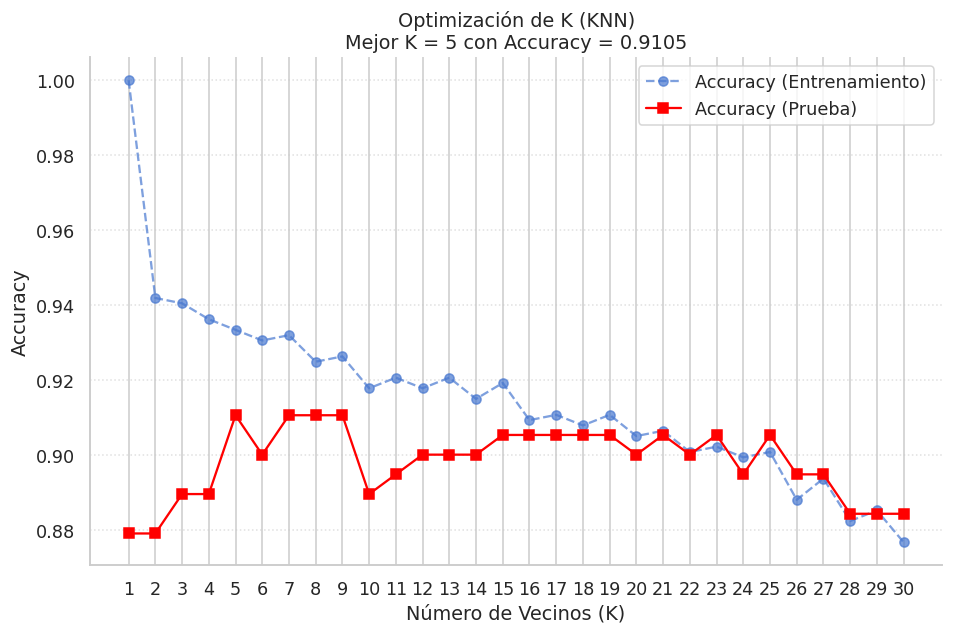

El valor óptimo detectado es K = 5 con un Accuracy en Test de 0.9105.


In [ ]:
import matplotlib.pyplot as plt

# Listas para almacenar resultados
k_values = range(1, 31)
train_accuracies = []
test_accuracies = []

print("Buscando el valor óptimo de K...")

for k in k_values:
    # Definición del Pipeline con el K actual
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    # Entrenamiento (usando X_train e y_train que contienen x1 y x2)
    pipeline.fit(X_train, y_train)

    # Cálculo de métricas
    train_accuracies.append(pipeline.score(X_train, y_train))
    test_accuracies.append(pipeline.score(X_test, y_test))

# Identificación del mejor K
best_test_acc = max(test_accuracies)
best_k = k_values[test_accuracies.index(best_test_acc)]

# Visualización de la Curva de Validación
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, label='Accuracy (Entrenamiento)', marker='o', linestyle='--', alpha=0.7)
plt.plot(k_values, test_accuracies, label='Accuracy (Prueba)', marker='s', color='red')

# Estética del gráfico
plt.title(f'Optimización de K (KNN)\nMejor K = {best_k} con Accuracy = {best_test_acc:.4f}')
plt.xlabel('Número de Vecinos (K)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(True, axis='y', linestyle=':', alpha=0.6)
plt.show()

print(f"El valor óptimo detectado es K = {best_k} con un Accuracy en Test de {best_test_acc:.4f}.")

El análisis de la curva de validación permite determinar que el valor óptimo para el modelo es **K = 5**, alcanzando un Accuracy del **91.05%** en el conjunto de prueba. Este resultado es fundamental porque representa el punto de equilibrio en el compromiso entre sesgo y varianza: mientras que valores de K muy bajos (como K=1) provocan un sobreajuste (*overfitting*) al intentar seguir cada punto individual de ruido, valores demasiado elevados tienden al subajuste (*underfitting*) al suavizar excesivamente la frontera de decisión y perder la forma circular característica de los datos. Al seleccionar K=5, garantizamos que el modelo capture la estructura geométrica del dataset con la máxima capacidad de generalización ante datos nuevos.

### Conclusión General: Validación de Hipótesis

Tras el desarrollo experimental, se presentan las conclusiones finales contrastadas con las hipótesis iniciales:

1. Se confirmó que el balanceo del target permitió utilizar el *Accuracy* como una métrica robusta, sin los sesgos típicos de los datasets desbalanceados.
2. La hipótesis fue correcta. El Modelo B (solo $x1$ y $x2$) alcanzó un 90% de accuracy, demostrando que la señal predictiva reside casi exclusivamente en estas dos variables.
3. Se validó empíricamente mediante el Modelo C (solo ruido, 50% accuracy = azar) y el Modelo A (todas las variables), donde la inclusión de estas columnas degradó el desempeño del KNN del 90% al 75% debido a la 'maldición de la dimensionalidad'.
4. La Regresión Logística inicial falló (Recall 0% en Clase 1), confirmando que la frontera es circular y no linealmente separable en el espacio original.
5. La creación de la variable `dist` ($x1^2 + x2^2$) permitió a la Regresión Logística subir de un 56% a un 69% de accuracy, validando que el conocimiento geométrico permite linearizar el problema para modelos simples.
6. La limpieza mediante IQR en el set de entrenamiento permitió que modelos sensibles como KNN y Árboles de Decisión definieran fronteras más estables y menos influenciadas por valores extremos, mejorando la capacidad de generalización.

**Veredicto:** Todas las hipótesis planteadas en la etapa de exploración fueron validadas, destacando que para este problema, un modelo no lineal (KNN) sobre un set de variables curado ($x1$, $x2$) es la solución óptima.

#Reflexión integral del trabajo práctico